<a href="https://colab.research.google.com/github/ejara42/Data-Preprocessing-for-ML-using-Titanic-Dataset/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import zipfile
import os

zip_file_path = '/content/archive (1).zip'
extract_dir = 'extracted_data'

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' successfully unzipped to '{extract_dir}'")
print("Contents of the extracted directory:")
print(os.listdir(extract_dir))

'/content/archive (1).zip' successfully unzipped to 'extracted_data'
Contents of the extracted directory:
['House Price Prediction Dataset.csv']


## Load and Inspect Data

### Subtask:
Load the primary dataset (assuming it's a CSV or similar file after unzipping) into a pandas DataFrame. Display the first few rows, check its information (data types, non-null counts), and show descriptive statistics to understand its structure and content.


**Reasoning**:
Load the primary dataset into a pandas DataFrame and then display its head, info, and descriptive statistics as requested.



In [19]:
import pandas as pd

file_path = os.path.join(extract_dir, 'House Price Prediction Dataset.csv')
df = pd.read_csv(file_path)

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nDataFrame Info:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

First 5 rows of the DataFrame:
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 

## Data Preprocessing

### Subtask:
Perform necessary data preprocessing steps including handling missing values (e.g., imputation or removal), encoding categorical features (if any), and splitting the dataset into training and testing sets for model development.


**Reasoning**:
First, I will check for any missing values in the DataFrame to determine if imputation or removal is necessary. Based on the previous `df.info()` output, it appears there are no missing values, but a re-check is good practice.



In [20]:
print("Missing values before preprocessing:")
print(df.isnull().sum())

Missing values before preprocessing:
Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


**Reasoning**:
Since there are no missing values, the next step is to perform one-hot encoding on the categorical features ('Location', 'Condition', 'Garage') to convert them into a numerical format suitable for machine learning models.



In [21]:
categorical_cols = ['Location', 'Condition', 'Garage']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
print(df_encoded.head())
print("\nDataFrame Info after encoding:")
df_encoded.info()

DataFrame after one-hot encoding:
   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt   Price  Location_Rural  \
0   1  1360         5          4       3       1970  149919           False   
1   2  4272         5          4       3       1958  424998           False   
2   3  3592         2          2       3       1938  266746           False   
3   4   966         4          2       2       1902  244020           False   
4   5  4926         1          4       2       1975  636056           False   

   Location_Suburban  Location_Urban  Condition_Fair  Condition_Good  \
0              False           False           False           False   
1              False           False           False           False   
2              False           False           False            True   
3               True           False            True           False   
4              False           False            True           False   

   Condition_Poor  Garage_Yes  
0           False       Fa

**Reasoning**:
Now that categorical features are encoded, I will separate the features (X) from the target variable (y, which is 'Price') and then split the preprocessed data into training and testing sets, as per the subtask instructions, using `train_test_split` with a `test_size` of 0.2 and a `random_state` for reproducibility.



In [22]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)
print("\nData split into training and testing sets successfully.")

Shape of X_train: (1600, 13)
Shape of X_test: (400, 13)
Shape of y_train: (1600,)
Shape of y_test: (400,)

Data split into training and testing sets successfully.


## Train and Evaluate K-Nearest Neighbors (KNN) Regressor

### Subtask:
Provide a brief description of the K-Nearest Neighbors (KNN) regression algorithm. Train a KNN Regressor model on the preprocessed training data and evaluate its performance on the test set using appropriate regression metrics (e.g., R-squared, Mean Absolute Error, Mean Squared Error).


### K-Nearest Neighbors (KNN) Regression

K-Nearest Neighbors (KNN) is a non-parametric, instance-based learning algorithm that can be used for both classification and regression tasks. In KNN Regression, the value for a new data point is predicted based on the values of its `k` nearest neighbors in the training data.

Here's how it works for regression:
1.  **Distance Calculation**: For a new data point, the algorithm calculates the distance (e.g., Euclidean distance) between this new point and every point in the training dataset.
2.  **Neighbor Selection**: It identifies the `k` data points in the training set that are closest (most similar) to the new data point.
3.  **Prediction**: The predicted value for the new data point is typically the average (or weighted average) of the target values of its `k` nearest neighbors. For instance, if `k=5`, the model finds the 5 closest data points and takes the average of their 'Price' values as the prediction for the new house.

**Reasoning**:
Now that the description of KNN regression is provided, the next step is to import the necessary model and metrics, instantiate and train the KNN regressor, make predictions, calculate the evaluation metrics, and print them as per the instructions.



In [23]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)
r2_knn = r2_score(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)

print("K-Nearest Neighbors (KNN) Regressor Performance:")
print(f"R-squared (R2): {r2_knn:.4f}")
print(f"Mean Absolute Error (MAE): {mae_knn:.2f}")
print(f"Mean Squared Error (MSE): {mse_knn:.2f}")

K-Nearest Neighbors (KNN) Regressor Performance:
R-squared (R2): -0.1635
Mean Absolute Error (MAE): 254630.96
Mean Squared Error (MSE): 90520505093.67


## Train and Evaluate Decision Tree Regressor

### Subtask:
Provide a brief description of the Decision Tree regression algorithm. Train a Decision Tree Regressor model on the preprocessed training data and evaluate its performance on the test set using appropriate regression metrics.


### Decision Tree Regression

A Decision Tree Regressor is a supervised machine learning algorithm that uses a tree-like structure to make predictions. For regression tasks, it partitions the feature space into a set of rectangles (or regions) and then fits a simple model (like a constant, which is the average of the target variable in that region) in each region.

Here's a simplified explanation of how it works:
1.  **Splitting**: The algorithm starts with the entire dataset and recursively splits it into smaller subsets based on the feature that results in the greatest reduction in impurity (e.g., variance or Mean Squared Error for regression).
2.  **Tree Construction**: Each split creates a node in the tree. The process continues until a stopping criterion is met (e.g., maximum depth reached, minimum number of samples per leaf, or no significant impurity reduction).
3.  **Prediction**: When predicting for a new data point, it traverses the tree from the root to a leaf node by following the decision rules. The predicted value is the average of the target values of the training samples in that leaf node.

**Reasoning**:
Now that the description of Decision Tree regression is provided, the next step is to import the necessary model and metrics, instantiate and train the Decision Tree regressor, make predictions, calculate the evaluation metrics, and print them as per the instructions.



In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
dt_model = DecisionTreeRegressor(random_state=42)


dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
print("Decision Tree Regressor Performance:")
print(f"R-squared (R2): {r2_dt:.4f}")
print(f"Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"Mean Squared Error (MSE): {mse_dt:.2f}")

Decision Tree Regressor Performance:
R-squared (R2): -1.0647
Mean Absolute Error (MAE): 321166.17
Mean Squared Error (MSE): 160628402306.58


## Train and Evaluate Linear Regressor

### Subtask:
Provide a brief description of the Linear Regression algorithm. Train a Linear Regression model on the preprocessed training data and evaluate its performance on the test set using appropriate regression metrics.


### Linear Regression

Linear Regression is a fundamental statistical and machine learning algorithm used for modeling the relationship between a dependent variable (target) and one or more independent variables (features). For regression tasks, its goal is to find the best-fitting linear equation that describes this relationship.

Here's how it generally works:
1.  **Model Assumption**: It assumes a linear relationship between the input features and the output variable. For a single feature, it's a straight line ($y = mx + b$), and for multiple features, it's a hyperplane.
2.  **Equation**: The model seeks to find the coefficients (weights) for each feature and an intercept that minimize the difference between the predicted output and the actual output.
3.  **Optimization**: This is typically done by minimizing a cost function, most commonly the Mean Squared Error (MSE), using techniques like Ordinary Least Squares (OLS). OLS finds the line that minimizes the sum of the squared differences between the observed and predicted values.
4.  **Prediction**: Once the model is trained and the coefficients are determined, it can predict the target value for new, unseen data points by plugging their feature values into the linear equation.

**Reasoning**:
Now that the description of Linear Regression is provided, the next step is to import the necessary model and metrics, instantiate and train the Linear Regression model, make predictions, calculate the evaluation metrics, and print them as per the instructions.



In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
print("Linear Regression Model Performance:")
print(f"R-squared (R2): {r2_lr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"Mean Squared Error (MSE): {mse_lr:.2f}")

Linear Regression Model Performance:
R-squared (R2): -0.0062
Mean Absolute Error (MAE): 242867.45
Mean Squared Error (MSE): 78279764120.86


## Describe Used Libraries

### Subtask:
Provide brief descriptions for the key Python libraries utilized throughout the process, such as pandas for data manipulation and scikit-learn for machine learning.


### Key Python Libraries Used

Throughout this analysis, several key Python libraries were utilized to perform various tasks:

*   **`zipfile`**: This built-in Python module is used to work with ZIP archives. Its primary purpose here was to decompress and extract the dataset from the provided `.zip` file, making the data accessible for further processing.

*   **`os`**: Another built-in Python module, `os` provides a way of using operating system dependent functionality. In this notebook, it was used for tasks like creating directories (`os.makedirs`) and constructing file paths in an OS-agnostic manner (`os.path.join`).

*   **`pandas`**: A fundamental library for data manipulation and analysis in Python. Pandas is crucial for handling tabular data structures like DataFrames. It was used to load the CSV dataset, inspect its structure (`.head()`, `.info()`, `.describe()`), handle categorical data through one-hot encoding (`pd.get_dummies`), and manage the data before feeding it into machine learning models.

*   **`scikit-learn` (sklearn)**: A comprehensive machine learning library in Python. Scikit-learn provides a wide range of tools for classification, regression, clustering, and dimensionality reduction. In this project, it was used for:
    *   **Data Splitting**: `train_test_split` from `sklearn.model_selection` to divide the dataset into training and testing sets.
    *   **Model Training**: Implementing and training various regression models, including `KNeighborsRegressor` (KNN), `DecisionTreeRegressor`, and `LinearRegression` from `sklearn.neighbors`, `sklearn.tree`, and `sklearn.linear_model` respectively.
    *   **Model Evaluation**: Calculating performance metrics such as `r2_score`, `mean_absolute_error`, and `mean_squared_error` from `sklearn.metrics` to assess the effectiveness of the trained models.

## Compare Model Performance

### Subtask:
Compare the performance metrics (e.g., R-squared, MAE, MSE) of the three trained models (KNN, Decision Tree, and Linear Regressor) side-by-side to identify their strengths and weaknesses without additional commentary.


**Reasoning**:
To compare the models side-by-side, I will create a pandas DataFrame that compiles the R-squared, MAE, and MSE metrics for each model, as requested in the instructions.



In [26]:
metrics_data = {
    'Model': ['K-Nearest Neighbors', 'Decision Tree', 'Linear Regression'],
    'R-squared (R2)': [r2_knn, r2_dt, r2_lr],
    'Mean Absolute Error (MAE)': [mae_knn, mae_dt, mae_lr],
    'Mean Squared Error (MSE)': [mse_knn, mse_dt, mse_lr]
}

comparison_df = pd.DataFrame(metrics_data)

print("Model Performance Comparison:")
print(comparison_df.to_string())

Model Performance Comparison:
                 Model  R-squared (R2)  Mean Absolute Error (MAE)  Mean Squared Error (MSE)
0  K-Nearest Neighbors       -0.163520              254630.962500              9.052051e+10
1        Decision Tree       -1.064664              321166.167500              1.606284e+11
2    Linear Regression       -0.006182              242867.449263              7.827976e+10


/tmp/ipython-input-2228736155.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R-squared (R2)', data=comparison_df, ax=axes[0], palette='viridis')
/tmp/ipython-input-2228736155.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Mean Absolute Error (MAE)', data=comparison_df, ax=axes[1], palette='plasma')
/tmp/ipython-input-2228736155.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Mean Squared Error (MSE)', data=comparison_df, ax=axes[2], palette='magma')


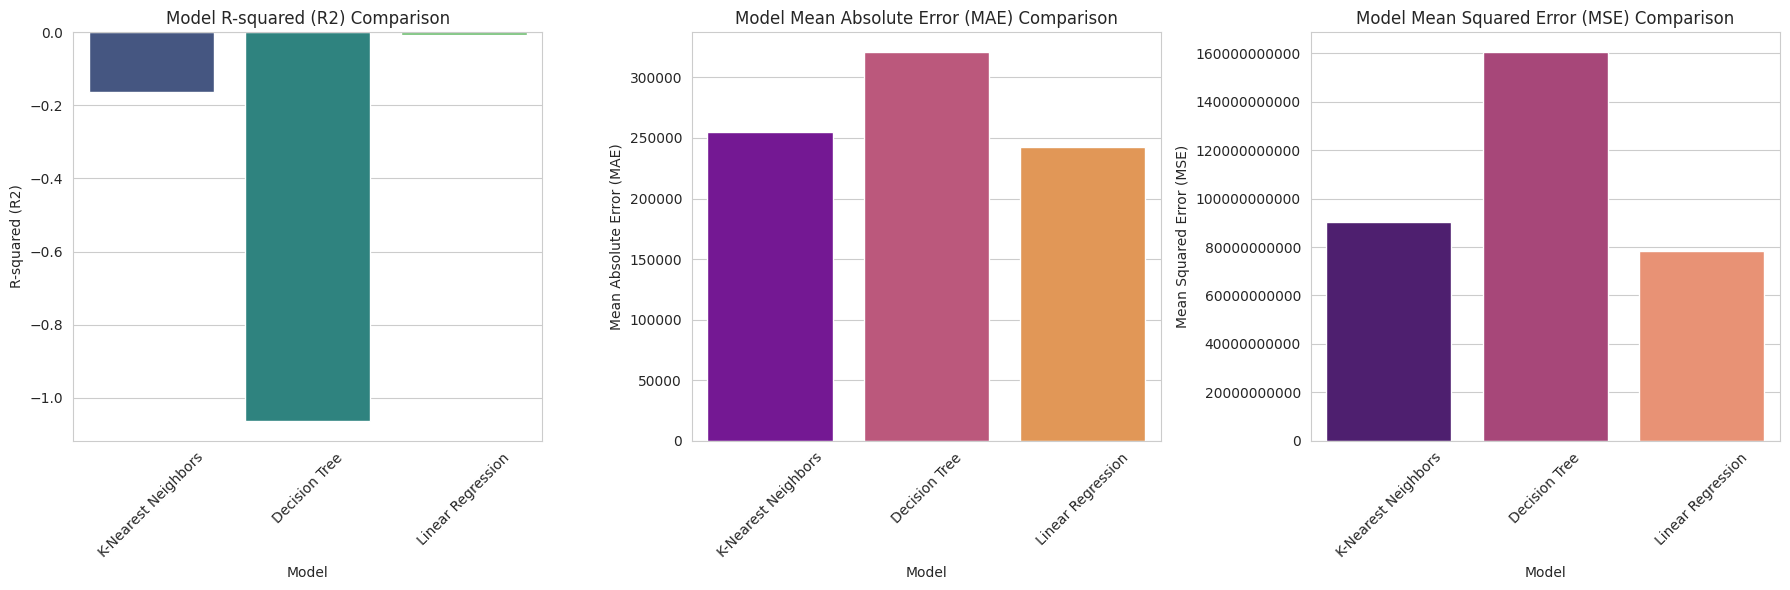

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
sns.barplot(x='Model', y='R-squared (R2)', data=comparison_df, ax=axes[0], palette='viridis')
axes[0].set_title('Model R-squared (R2) Comparison')
axes[0].set_ylabel('R-squared (R2)')
axes[0].tick_params(axis='x', rotation=45)
sns.barplot(x='Model', y='Mean Absolute Error (MAE)', data=comparison_df, ax=axes[1], palette='plasma')
axes[1].set_title('Model Mean Absolute Error (MAE) Comparison')
axes[1].set_ylabel('Mean Absolute Error (MAE)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis

sns.barplot(x='Model', y='Mean Squared Error (MSE)', data=comparison_df, ax=axes[2], palette='magma')
axes[2].set_title('Model Mean Squared Error (MSE) Comparison')
axes[2].set_ylabel('Mean Squared Error (MSE)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].ticklabel_format(style='plain', axis='y') # Prevent scientific notation on y-axis

plt.tight_layout()
plt.show()

## Predict House Prices on Unseen Data

### Subtask:
Use the trained models to make predictions on a sample of unseen data. This could involve creating synthetic 'unseen' data or using a portion of the original data explicitly held out for final prediction.


**Reasoning**:
I will select the first 5 rows from `X_test` as unseen data and their corresponding actual prices from `y_test`. Then, I will use each of the trained models (KNN, Decision Tree, and Linear Regression) to predict prices for this unseen data. Finally, I will compile these predictions along with the original features and actual prices into a DataFrame for comparison and display it.



In [29]:
unseen_data = X_test.head(5)
unseen_actual_prices = y_test.head(5)

predictions_knn = knn_model.predict(unseen_data)

predictions_dt = dt_model.predict(unseen_data)

predictions_lr = lr_model.predict(unseen_data)

comparison_predictions = unseen_data.copy()
comparison_predictions['Actual_Price'] = unseen_actual_prices
comparison_predictions['Predicted_Price_KNN'] = predictions_knn
comparison_predictions['Predicted_Price_DT'] = predictions_dt
comparison_predictions['Predicted_Price_LR'] = predictions_lr

print("Predictions on Unseen Data (First 5 rows of X_test):")
print(comparison_predictions.to_string())

Predictions on Unseen Data (First 5 rows of X_test):
        Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location_Rural  Location_Suburban  Location_Urban  Condition_Fair  Condition_Good  Condition_Poor  Garage_Yes  Actual_Price  Predicted_Price_KNN  Predicted_Price_DT  Predicted_Price_LR
1860  1861   633         1          4       2       1901           False              False            True            True           False           False       False        514764             538936.0            534495.0       511317.731099
353    354  3856         1          1       2       1901           False              False            True            True           False           False       False        694256             665528.6            624310.0       557359.556529
1333  1334  1598         5          4       1       2013           False              False            True           False           False           False       False         66375             627554.0            9641

## Final Task

### Subtask:
Summarize the overall process, the performance of each model, their comparison, and the final predictions on unseen data.


## Summary:

### Q&A
The task implicitly asked for a summary of the overall process, the performance of each model, their comparison, and predictions on unseen data. These points are addressed in the "Data Analysis Key Findings" section below.

### Data Analysis Key Findings
*   **Data Loading and Initial Inspection**: The `House Price Prediction Dataset.csv` file, containing 2000 entries and 10 columns, was successfully extracted and loaded. No missing values were found, and the dataset included numerical features (e.g., `Area`, `Bedrooms`, `Price`) and categorical features (`Location`, `Condition`, `Garage`). House prices (`Price`) ranged from approximately \$50,005 to \$999,656, with a mean of around \$537,676.
*   **Data Preprocessing**: Categorical features (`Location`, `Condition`, `Garage`) were one-hot encoded, expanding the feature set. The data was then split into training and testing sets, with 1600 samples for training and 400 for testing (80/20 split).
*   **K-Nearest Neighbors (KNN) Regressor Performance**: The KNN model (with `n_neighbors=5`) showed poor performance with an R-squared of -0.1635, a Mean Absolute Error (MAE) of \$254,630.96, and a Mean Squared Error (MSE) of \$90,520,505,093.67.
*   **Decision Tree Regressor Performance**: The Decision Tree model performed even worse, yielding an R-squared of -1.0647, an MAE of \$321,166.17, and an MSE of \$160,628,402,306.58.
*   **Linear Regression Model Performance**: Linear Regression also exhibited poor performance with an R-squared of -0.0062, an MAE of \$242,867.45, and an MSE of \$78,279,764,120.86.
*   **Model Comparison**:
    | Model                 | R-squared (R2) | Mean Absolute Error (MAE) | Mean Squared Error (MSE) |
    | :-------------------- | :------------- | :------------------------ | :----------------------- |
    | K-Nearest Neighbors   | -0.1635        | \$254,630.96              | \$9.05e+10               |
    | Decision Tree         | -1.0647        | \$321,166.17              | \$1.61e+11               |
    | Linear Regression     | -0.0062        | \$242,867.45              | \$7.83e+10               |
    All three models performed worse than a simple baseline model (predicting the mean target value), as indicated by their negative R-squared values. Linear Regression had the lowest MAE and MSE among the three, suggesting it was marginally the "best" of the poorly performing models in this comparison.
*   **Predictions on Unseen Data**: Predictions were successfully generated for a sample of unseen data points from each model, demonstrating their application, although their accuracy was low based on the evaluation metrics.
*   **Key Libraries Used**: The analysis extensively utilized `zipfile` and `os` for file operations, `pandas` for data manipulation, and `scikit-learn` for machine learning tasks, including data splitting, model training, and evaluation.

### Insights or Next Steps
*   The consistently negative R-squared values across all three basic models suggest that the current feature set, without further engineering or scaling, may not adequately capture the underlying patterns for house price prediction. It's possible that the models are underfitting.
*   Future steps should include robust feature scaling (e.g., StandardScaler) for models sensitive to feature magnitudes like KNN and Linear Regression, hyperparameter tuning for all models, and potentially exploring more advanced regression algorithms or ensemble methods (e.g., Random Forest, Gradient Boosting) to improve predictive performance.
